# 20_异常值处理方法-中位数填充

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


本小节和大家详细的讲解，常值处理方法中的中位数填充处理方式\~

### 什么是异常值？

在一堆数字里，有时候会混进一些“奇怪”的数字，跟其他数字差距特别大，比如其他都是80、90、85，突然来个300，这种数就叫**异常值**。

它们可能是**测量错误**、**录入错误**，或者确实是罕见的特殊情况。但这些异常值可能会**干扰我们的统计分析或模型训练**。

### 中位数填充法？

如果我们发现某些数据是异常值，想要把它“处理掉”，有一种方法叫**中位数填充**：

就是**用这列数据的中位数**，把那些异常的值**替换掉**。

### 举个例子：

你有一组工资数据：`[4000, 4200, 3900, 4100, 3950, 80000]`

很明显，80000这个工资像是个异常值，因为和其他的差太多了。

这时候我们用中位数填充：

- 先把数据从小到大排序：`[3900, 3950, 4000, 4100, 4200, 80000]`
- 中位数是中间两个数的平均：`(4000 + 4100)/2 = 4050`
- 把80000换成4050 ⇒ `[4000, 4200, 3900, 4100, 3950, **4050**]`

这样，数据就“平稳”多了。

### 为什么用中位数？不用平均值（均值）？

因为**平均值容易被异常值影响**，而**中位数不容易受极端值干扰**。

举个例子：

- 原工资数据：[4000, 4200, 3900, 4100, 3950, 80000]
- 平均值 = 总和 / 个数 = (4000+4200+3900+4100+3950+80000)/6 = **16258.3**

你看，原本数据都在4000左右，但平均值直接飙到16000+，被80000拖上去了，**这时候平均值就不靠谱了**。

而中位数 = **4050**，更能代表“真实中间水平”。

## 核心原理

### 1. 中位数定义：

给定一个数据集合 $X = \{x_1, x_2, ..., x_n\}$，我们先将其**从小到大排序**。

- 如果 $n$ 是奇数：  
中位数 $\tilde{x} = x_{\frac{n+1}{2}}$
- 如果 $n$ 是偶数：  
中位数 $\tilde{x} = \frac{x_{\frac{n}{2}} + x_{\frac{n}{2} + 1}}{2}$

这个中位数反映的是**数据的中间位置值**，而不是平均水平。

### 2. 异常值判断的公式基础（常用方法）：

为了找出哪些是异常值，我们可以用**四分位距法（IQR）**：

- 第1四分位数（Q1）是25%的位置
- 第3四分位数（Q3）是75%的位置
- 四分位距：$IQR = Q3 - Q1$

然后定义异常值的标准：

- 低于：$Q1 - 1.5 \times IQR$
- 高于：$Q3 + 1.5 \times IQR$  
→ 超出这个范围的，就可能是异常值。

**举例说明**：

数据：`[1, 2, 3, 4, 5, 6, 100]`

- 排序：`[1, 2, 3, 4, 5, 6, 100]`
- Q1 = 2
- Q3 = 6
- IQR = 6 - 2 = 4
- 上限 = 6 + 1.5×4 = 12
- 下限 = 2 - 1.5×4 = -4

所以，**100 > 12 ⇒ 是异常值**

## 中位数填充的算法流程

**输入**：一列数值型数据 $X = [x_1, x_2, ..., x_n]$

**步骤**：

**第一步：找出异常值**

- 使用 IQR 方法计算 Q1、Q3、IQR
- 判断每个 $x_i$ 是否满足：


$$
x_i < Q1 - 1.5 \times IQR \quad \text{或} \quad x_i > Q3 + 1.5 \times IQR
$$


- 满足的就是异常值

**第二步：计算中位数**

- 排序后，计算中位数 $\tilde{x}$ 如前所述

**第三步：替换异常值**

- 对每个 $x_i$，如果它是异常值，替换为 $\tilde{x}$

**第四步：输出处理后的数据集**

可以记住一句话：中位数填充是一种“稳健”的方式，处理数据中那些太奇怪的数字时，特别好用！

## 完整案例

我们模拟一个关于公司员工“月销售额”数据的场景。假设某公司销售部门提供了一份月度员工销售数据，但由于系统错误或数据录入问题，个别员工的销售额出现了极高的异常值。

#### 问题

- 我们如何检测这些异常值？
- 是否应该删掉这些值？
- 如果不能删除，用什么方法“平滑”这些异常？

**解决方案：使用中位数填充法。**

#### 数据构建思路

我们将构造一份拥有**100个员工月销售额**的数据集，数据大部分围绕在正常范围内（5,000 \~ 10,000），但插入了几个离群值（如100,000+），模拟“异常销售记录”。

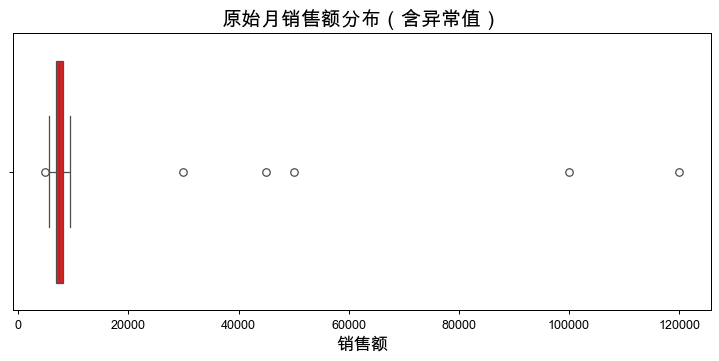

检测到的异常值：
    Employee_ID  Monthly_Sales  Is_Outlier
74           75    4880.254896        True
95           96   30000.000000        True
96           97   45000.000000        True
97           98  100000.000000        True
98           99  120000.000000        True
99          100   50000.000000        True


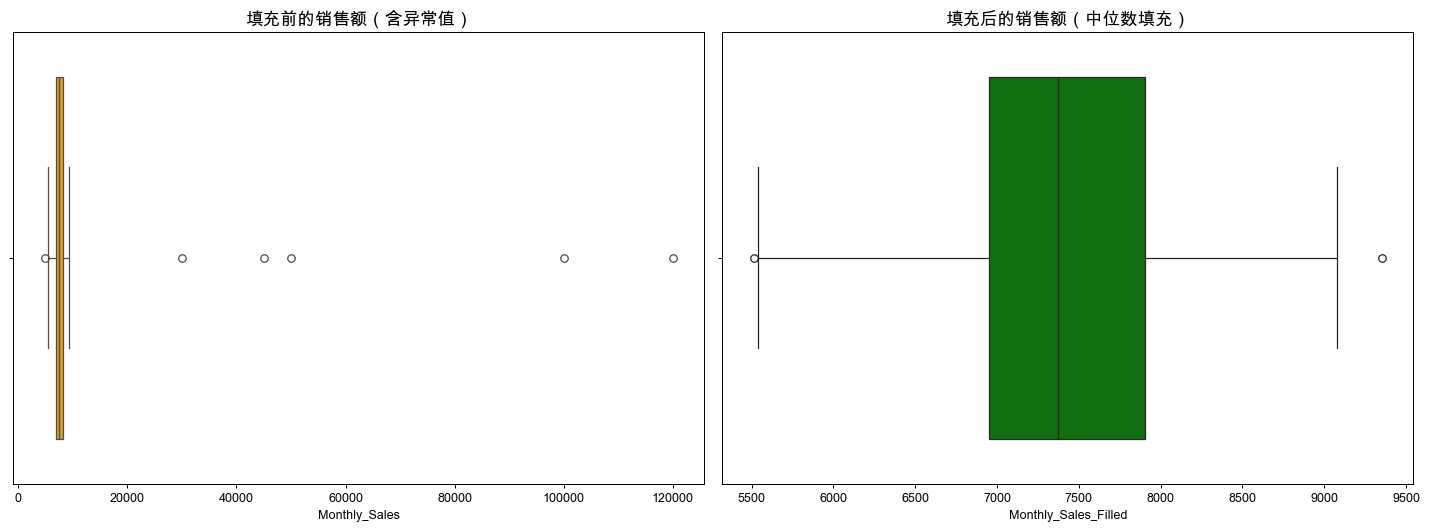

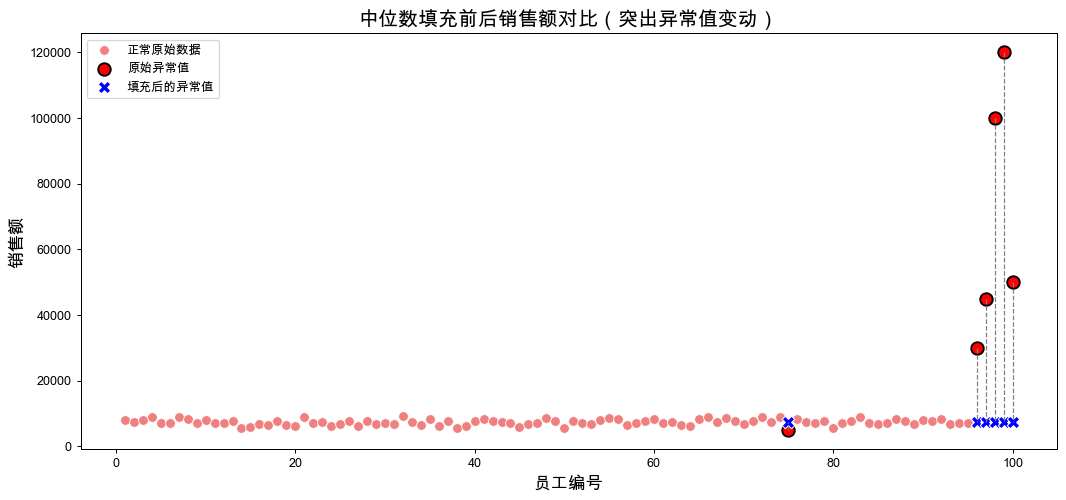

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# 1. 模拟月销售额数据
np.random.seed(42)
normal_sales = np.random.normal(loc=7500, scale=1000, size=95)  # 正常销售额
outliers = np.array([30000, 45000, 100000, 120000, 50000])       # 模拟异常值
sales_data = np.concatenate((normal_sales, outliers))

# 构造DataFrame
df = pd.DataFrame({'Employee_ID': range(1, 101), 'Monthly_Sales': sales_data})

# 2. 初始数据分布图（含异常值）
plt.figure(figsize=(10, 4))
plt.title("原始月销售额分布（含异常值）", fontsize=16)
sns.boxplot(x=df['Monthly_Sales'], color="red")
plt.xlabel("销售额", fontsize=14)
plt.show()

# 3. 异常值检测（IQR法）
Q1 = df['Monthly_Sales'].quantile(0.25)
Q3 = df['Monthly_Sales'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 标记异常值
df['Is_Outlier'] = (df['Monthly_Sales'] < lower_bound) | (df['Monthly_Sales'] > upper_bound)

# 打印异常值
print("检测到的异常值：")
print(df[df['Is_Outlier']])

# 4. 使用中位数替换异常值
median_value = df.loc[~df['Is_Outlier'], 'Monthly_Sales'].median()
df['Monthly_Sales_Filled'] = df['Monthly_Sales'].copy()
df.loc[df['Is_Outlier'], 'Monthly_Sales_Filled'] = median_value

# 5. 可视化填充前后比较（箱线图）
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(x=df['Monthly_Sales'], ax=axes[0], color="orange")
axes[0].set_title("填充前的销售额（含异常值）", fontsize=14)

sns.boxplot(x=df['Monthly_Sales_Filled'], ax=axes[1], color="green")
axes[1].set_title("填充后的销售额（中位数填充）", fontsize=14)

plt.tight_layout()
plt.show()

# 6. 可视化中值填充效果（散点对比 + 异常点高亮 + 连接线）
plt.figure(figsize=(14, 6))

# 6.1 绘制正常点（原始值）
sns.scatterplot(x='Employee_ID', y='Monthly_Sales', data=df[~df['Is_Outlier']],
                label='正常原始数据', s=60, color='lightcoral', marker='o')

# 6.2 绘制异常点（原始值）
sns.scatterplot(x='Employee_ID', y='Monthly_Sales', data=df[df['Is_Outlier']],
                label='原始异常值', s=100, color='red', marker='o', edgecolor='black', linewidth=1.5)

# 6.3 绘制异常点（替换后的值）
sns.scatterplot(x='Employee_ID', y='Monthly_Sales_Filled', data=df[df['Is_Outlier']],
                label='填充后的异常值', s=100, color='blue', marker='X')

# 6.4 添加连接线：原始异常值 → 替换后的中位数
for _, row in df[df['Is_Outlier']].iterrows():
    plt.plot([row['Employee_ID'], row['Employee_ID']],
             [row['Monthly_Sales'], row['Monthly_Sales_Filled']],
             color='gray', linestyle='--', linewidth=1)

plt.title("中位数填充前后销售额对比（突出异常值变动）", fontsize=16)
plt.xlabel("员工编号", fontsize=14)
plt.ylabel("销售额", fontsize=14)
plt.legend()
plt.show()

#### 1. 数据模拟

In [3]:
normal_sales = np.random.normal(loc=7500, scale=1000, size=95)
outliers = np.array([30000, 45000, 100000, 120000, 50000])

- 我们用 `np.random.normal()` 生成**95个接近7500元**的销售额数据，符合常见分布。
- 同时加入5个明显偏离的大值作为**异常值**。

#### 2. 可视化原始数据分布

<Axes: xlabel='Monthly_Sales'>

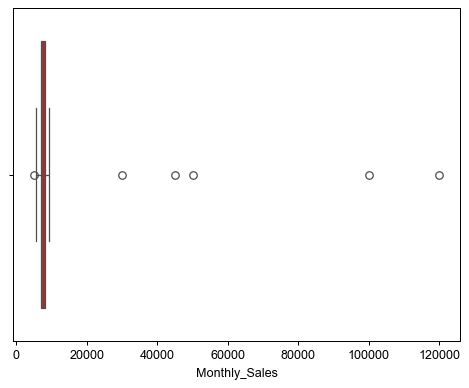

In [4]:
sns.boxplot(x=df['Monthly_Sales'], color="red")

- 采用盒须图（boxplot）来展示销售额的分布。
- 上下“胡须”之外的点是异常点。
- 图中能看到5个远离正常区域的红点。

![原文参考图，当前结果见代码输出](attachments/img_016.png)

#### 3. 异常值检测（IQR法）

In [5]:
Q1 = df['Monthly_Sales'].quantile(0.25)
Q3 = df['Monthly_Sales'].quantile(0.75)
IQR = Q3 - Q1

- 四分位距法是目前最常用的统计异常值检测方法之一。
- 异常值判断区间：


$$
x < Q1 - 1.5 \times IQR \quad 或 \quad x > Q3 + 1.5 \times IQR
$$


#### 4. 中位数填充

In [6]:
median_value = df.loc[~df['Is_Outlier'], 'Monthly_Sales'].median()

- 仅使用“非异常数据”来计算中位数，更准确。
- 将异常值位置替换为这个中位数。

#### 5. 可视化填充效果

两个图并排展示：

- 左边：异常值依然存在（盒须图长、分布不集中）
- 右边：填充后分布紧凑，中位数替换掉了极端值

![原文参考图，当前结果见代码输出](attachments/img_017.png)

#### 6. 散点图对比

直观展示了：

- 哪些数据点被中位数替换（红点变成蓝X）
- 填充效果如何影响整体趋势

![原文参考图，当前结果见代码输出](attachments/img_018.png)

#### 结果分析与讨论

- 原始数据的异常值造成了分布极端偏斜；
- 使用中位数后，数据变得集中，极端值被平滑；
- 大多数数据几乎没有变化，只处理了少数离群数据；
- 箱线图和散点图显示出中位数填充的直观效果，非常清晰。

### 中位数填充法优缺点分析

**优点**：

1. **稳健性强**：中位数不受极端值影响，因此填充值更“靠谱”；
2. **简单高效**：计算中位数很快，适用于大规模数据；
3. **保留样本数量**：不像删除法那样直接丢弃数据，适用于样本稀少的情况；
4. **适合数值型数据**：对销售额、温度、收入等数据类型效果很好；
5. **自动拉回数据分布**：让数据整体更“规整”，利于机器学习建模。

**缺点**：

1. **可能掩盖真实异常**：有些异常值是实际存在的关键数据（如高销售额），填充会丢失信息；
2. **破坏原始分布特征**：大量填充会影响均值、方差等统计特征；
3. **填充值是“伪造”的**：不反映真实业务过程，适用于统计分析但不适合财务等要求真实记录的领域；
4. **不能处理分类变量**：中位数是数值方法，不适用于文本型数据。

### 使用中位数填充的最佳场景分析

**最佳应用场景**：

1. 数据分布接近对称或轻微偏态的数据；
2. 异常值不是核心关注点，且很少见；
3. 对数据完整性有要求，不能删除样本的情况下；
4. 用于构建机器学习模型的前期数据清洗；
5. 异常值为输入变量（特征）而不是目标变量（label）时。

**不推荐使用场景**：

1. 异常值是业务关键指标（如高销售额、大客户流失值）；
2. 填充会掩盖真相的领域（医疗、生物实验等）；
3. 分类数据或多模态分布（多个中位数或无中位数概念）；
4. 数据中异常值占比很高（比如>10%）时，中位数已不再代表“中心”。

## 总结

中位数填充法是一种**稳健、快速、易实现**的异常值处理方法，尤其在样本数据较多、极端值明显时表现优异。

中位数填充法不是万能的，但在机器学习和统计分析的预处理环节中，是一个可靠且高性价比的选择。